--- Running Simulation: Baseline ---
--- Running Simulation: Brown ---


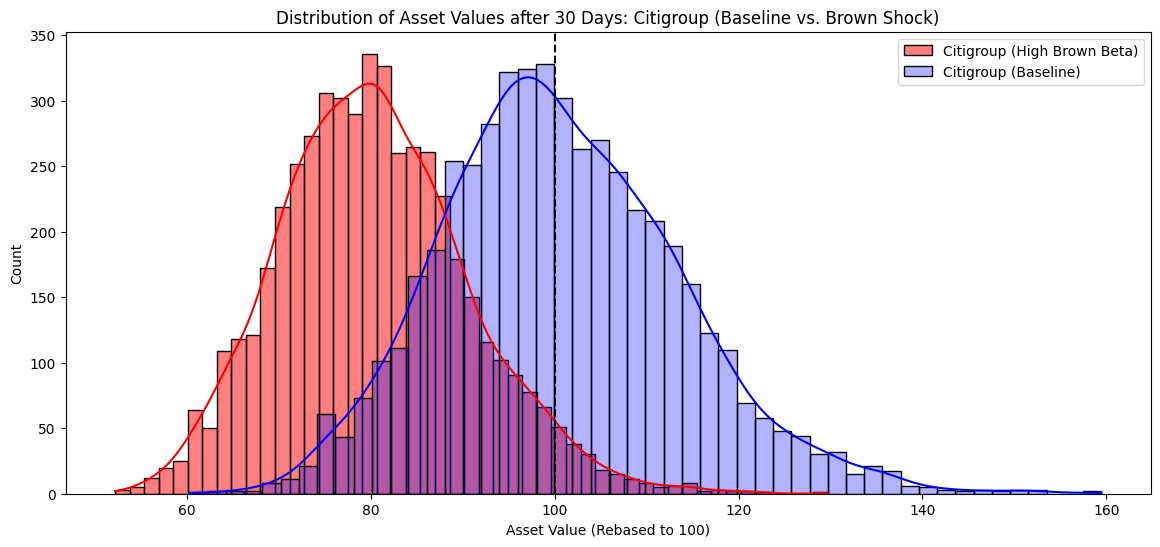


--- Risk Metrics (Citigroup) ---
Baseline Expected Shortfall (99%): -$29.00
Brown Shock Expected Shortfall (99%): -$42.78
Impact of ESG Shock: 47.5% increase in Tail Risk


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load Data
# We need the Returns, the GARCH params, and the ESG Betas
data_path = os.path.join("..", "..", "data", "processed")

returns_df = pd.read_csv(os.path.join(data_path, "market_returns.csv"), index_col=0, parse_dates=True)
esg_df = pd.read_csv(os.path.join(data_path, "esg_sensitivity.csv"), index_col=0)

# Filter only Clearing Members for the simulation
cm_tickers = ['JPM', 'GS', 'MS', 'BAC', 'C', 'DB', 'BCS']
cm_returns = returns_df[cm_tickers]

class CCPRiskEngine:
    def __init__(self, returns_data, esg_betas, num_sims=1000, horizon=20):
        """
        initializes the Monte Carlo Engine.
        :param returns_data: DataFrame of historical log returns
        :param esg_betas: DataFrame of Beta sensitivities
        :param num_sims: Number of Monte Carlo paths (default 1000 for speed, use 10k for final)
        :param horizon: Days to simulate (Margin Period of Risk, typically 5-20 days)
        """
        self.returns = returns_data
        self.esg_betas = esg_betas
        self.num_sims = num_sims
        self.horizon = horizon
        self.tickers = returns_data.columns.tolist()
        self.num_assets = len(self.tickers)
        
        # Calculate Correlation Matrix (Static for now, can make dynamic later)
        self.cov_matrix = returns_data.cov()
        self.corr_matrix = returns_data.corr()
        
        # Cholesky Decomposition for Correlated Random Numbers
        # This ensures that if JPM crashes, GS likely crashes too
        self.L = np.linalg.cholesky(self.corr_matrix)
        
    def generate_scenarios(self, shock_type=None, shock_magnitude=-0.20):
        """
        Runs the simulation.
        :param shock_type: 'Brown' (Energy Crash), 'Green' (Tech/Renewable Crash), or None (Normal)
        :param shock_magnitude: Size of the market crash (e.g., -0.20 for 20% drop)
        """
        dt = 1  # 1 day steps
        
        # Storage for all paths: Shape (Horizon, Simulations, Assets)
        paths = np.zeros((self.horizon, self.num_sims, self.num_assets))
        
        # Initial prices (normalized to 100 for easy comparison)
        current_prices = np.ones((self.num_sims, self.num_assets)) * 100
        
        print(f"--- Running Simulation: {shock_type if shock_type else 'Baseline'} ---")
        
        for t in range(self.horizon):
            # 1. Generate Uncorrelated Random Normal Shocks (Z)
            Z = np.random.normal(0, 1, size=(self.num_sims, self.num_assets))
            
            # 2. Correlate them using Cholesky (L * Z)
            correlated_shocks = np.dot(Z, self.L.T)
            
            # 3. Apply ESG Shock (Only on Day 1 for sudden impact)
            esg_impact = np.zeros((self.num_sims, self.num_assets))
            
            if t == 0 and shock_type is not None:
                if shock_type == 'Brown':
                    # Impact = Shock * Brown_Beta
                    betas = self.esg_betas.loc[self.tickers, 'Brown_Beta (XLE)'].values
                    impact_vector = shock_magnitude * betas
                    
                elif shock_type == 'Green':
                    betas = self.esg_betas.loc[self.tickers, 'Green_Beta (ICLN)'].values
                    impact_vector = shock_magnitude * betas
                
                # Broadcast impact to all simulations
                esg_impact = np.tile(impact_vector, (self.num_sims, 1))

            # 4. Calculate Periodic Daily Returns
            # Simplified GBM: Drift assumed 0 for short-term stress testing
            daily_vol = self.returns.std().values 
            
            # r = sigma * shock + ESG_impact
            # Note: We are adding the discrete jump (ESG impact) to the diffusion process
            simulated_returns = (daily_vol * correlated_shocks) + esg_impact
            
            # 5. Update Prices
            current_prices = current_prices * np.exp(simulated_returns)
            paths[t] = current_prices
            
        return paths

# --- Execution ---

# 1. Initialize Engine
engine = CCPRiskEngine(cm_returns, esg_df, num_sims=5000, horizon=30)

# 2. Run Baseline Simulation (Normal Market)
baseline_paths = engine.generate_scenarios(shock_type=None)

# 3. Run "Brown Crash" Scenario (Oil drops 30%)
# This simulates a rapid devaluation of fossil fuel assets (Transition Risk)
brown_shock_paths = engine.generate_scenarios(shock_type='Brown', shock_magnitude=-0.30)

# 4. Visualization: Compare JPM (Generic) vs C (High Beta) in Brown Shock
# We extract the final prices (at day 30) for visualization
jpm_idx = cm_tickers.index('JPM')
c_idx = cm_tickers.index('C')

plt.figure(figsize=(14, 6))

# Plot Citigroup Distribution
sns.histplot(brown_shock_paths[-1, :, c_idx], color='red', alpha=0.5, label='Citigroup (High Brown Beta)', kde=True)
sns.histplot(baseline_paths[-1, :, c_idx], color='blue', alpha=0.3, label='Citigroup (Baseline)', kde=True)

plt.axvline(100, color='black', linestyle='--')
plt.title("Distribution of Asset Values after 30 Days: Citigroup (Baseline vs. Brown Shock)")
plt.xlabel("Asset Value (Rebased to 100)")
plt.legend()
plt.show()

# 5. Calculate Expected Shortfall (ES) / Tail Risk
# How much value is lost in the worst 1% of cases?
def calc_es(final_prices, alpha=0.99):
    # Calculate loss relative to starting 100
    losses = 100 - final_prices
    # VaR is the quantile
    var = np.percentile(losses, alpha * 100)
    # ES is average of losses exceeding VaR
    es = losses[losses > var].mean()
    return es

es_base = calc_es(baseline_paths[-1, :, c_idx])
es_shock = calc_es(brown_shock_paths[-1, :, c_idx])

print(f"\n--- Risk Metrics (Citigroup) ---")
print(f"Baseline Expected Shortfall (99%): -${es_base:.2f}")
print(f"Brown Shock Expected Shortfall (99%): -${es_shock:.2f}")
print(f"Impact of ESG Shock: {((es_shock/es_base)-1)*100:.1f}% increase in Tail Risk")